# Exploration et consolidation des données de phénologie

L'objectif de ce notebook est de : 
- consolider les données de phénologie issues des différentes sources
- de filtrer les données en ne conservant que celles de la vigne et concernant la floraison
- de décrire les données
- de les enregistrer en un format exploitable lors des phases ultérieures

In [3]:
#Chargement des librairies
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import Point
import geopandas as gpd
import seaborn as sns

In [4]:
#Configuration
srcFolder = "../data/raw/tempo_202510201126/"
dstFolder = "../data/processed/consolidated/"
sources = [
    "agroclim_pheno.csv",
    "epiphyt.csv",
    "foret.csv",
    "ods_recherche.csv",
    "ods_tela_botanica.csv",
    "phenoclim_agroclim_inrae.csv",
    "phenoclim_crea_mont_blanc.csv",
    "phetec_inrae.csv",
    "variables_communes.csv"
]
colonnes = [
    'date', 
    'annee', 
    'jour_de_l_annee', 
    'source_donnees',
    'latitude_du_site', 
    'longitude_du_site',
    'altitude_du_site_ign',
    'regne', 
    'genre',
    'espece',
    'code_du_stade_phenologique'
]

filter_regne = 'Plantae'
filter_genre = 'Vitis'
filter_espece = 'vinifera'


## Consolidation des données de phénologie

In [5]:
#Récupération et combinaison des sources
dataFrames = []

for source in sources:
    print(f"Chargement source {source}...")
    
    data = pd.read_csv(
        srcFolder+source,
        encoding='ISO-8859-1', 
        sep=';',
        low_memory=False,
        usecols=colonnes
    )
    print(f"{data.shape[0]} lignes chargées !")
    dataFrames.append(data)
    print("----------------------------------------------")

allData = pd.concat(dataFrames, ignore_index=True)
print(f"Nombre total de résultats : {allData.shape[0]}")
allData['date'] = pd.to_datetime(allData['date'])
allData = allData[allData['date'] >= '1950-01-01']
print(f"Nombre de résultats > 1950 : {allData.shape[0]}")
allData.head(10)




Chargement source agroclim_pheno.csv...
7635 lignes chargées !
----------------------------------------------
Chargement source epiphyt.csv...
255818 lignes chargées !
----------------------------------------------
Chargement source foret.csv...
48070 lignes chargées !
----------------------------------------------
Chargement source ods_recherche.csv...
16090 lignes chargées !
----------------------------------------------
Chargement source ods_tela_botanica.csv...
11613 lignes chargées !
----------------------------------------------
Chargement source phenoclim_agroclim_inrae.csv...
8026 lignes chargées !
----------------------------------------------
Chargement source phenoclim_crea_mont_blanc.csv...
13075 lignes chargées !
----------------------------------------------
Chargement source phetec_inrae.csv...
126 lignes chargées !
----------------------------------------------
Chargement source variables_communes.csv...
360453 lignes chargées !
-----------------------------------------

,date,annee,jour_de_l_annee,source_donnees,latitude_du_site,longitude_du_site,altitude_du_site_ign,regne,genre,espece,code_du_stade_phenologique
13,1950-03-23,1950,82,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61
14,1950-04-14,1950,104,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,65
15,1951-04-03,1951,93,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61
1801,1965-04-13,1965,103,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,65
1802,1966-04-06,1966,96,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61
1875,1952-04-10,1952,101,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61
1876,1953-03-30,1953,89,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61
1877,1955-04-12,1955,102,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61
1878,1956-04-12,1956,103,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61
1879,1957-03-23,1957,82,AgroClim Pheno,48.8,2.08,136.0,Plantae,Acer,platanoides,61


In [6]:
#Affichage d'infos
allData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647834 entries, 13 to 720905
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   date                        647834 non-null  datetime64[ns]
 1   annee                       647834 non-null  int64         
 2   jour_de_l_annee             647834 non-null  int64         
 3   source_donnees              647834 non-null  object        
 4   latitude_du_site            647834 non-null  float64       
 5   longitude_du_site           647834 non-null  float64       
 6   altitude_du_site_ign        631510 non-null  float64       
 7   regne                       647834 non-null  object        
 8   genre                       647834 non-null  object        
 9   espece                      647834 non-null  object        
 10  code_du_stade_phenologique  647834 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3),

In [7]:
#Statistiques descriptives
allData.describe()

,date,annee,jour_de_l_annee,latitude_du_site,longitude_du_site,altitude_du_site_ign,code_du_stade_phenologique
count,647834,647834.000000,647834.000000,647834.000000,647834.000000,631510.000000,647834.000000
mean,2014-10-21 22:42:04.135504128,2014.428743,138.482855,46.661177,2.430085,192.369809,64.033570
min,1950-01-15 00:00:00,1950.000000,1.000000,41.571730,-4.760930,0.000000,60.000000
25%,2015-06-01 00:00:00,2015.000000,124.000000,44.786500,-0.063660,68.000000,61.000000
50%,2017-05-30 00:00:00,2017.000000,146.000000,46.950790,2.361290,132.000000,65.000000
75%,2019-05-27 00:00:00,2019.000000,158.000000,48.458050,4.833050,231.000000,67.000000
max,2025-09-29 00:00:00,2025.000000,366.000000,51.024110,9.528950,2258.000000,69.000000
std,NaN,10.381486,34.453682,2.121356,2.832285,227.503283,3.352017


In [8]:
#Données intéressantes
print(f"Année min : {allData.min(axis=0)['annee']}")
print(f"Année max : {allData.max(axis=0)['annee']}")
stades = allData["code_du_stade_phenologique"].unique()
print(f"Stades phénologiques : {stades}")
genres = allData["genre"].unique()
print(f"Genres : {genres}")
print("Stades phénologiques :")


Année min : 1950
Année max : 2025
Stades phénologiques : [61 65 69 60 68 66 63 67 62 64]
Genres : ['Acer' 'Corylus' 'Berberis' 'Colchicum' 'Crataegus' 'Ligustrum' 'Malus'
 'Phytolacca' 'Primula' 'Fagus' 'Ficaria' 'Forsythia' 'Pyrus' 'Prunus'
 'Solidago' 'Syringa' 'Tilia' 'Betula' 'Aesculus' 'Aucuba' 'Ilex'
 'Coriaria' 'Diervilla' 'Leucanthemum' 'Lilium' 'Osmanthus' 'Polygonum'
 'Ribes' 'Salvia' 'Sambucus' 'Viburnum' 'Bocconia' 'Buxus' 'Calycanthus'
 'Canna' 'Cerasus' 'Sorbus' 'Tussilago' 'Vitis' 'Triticum' 'Brassica'
 'Hordeum' 'Zea' 'Solanum' 'Phaseolus' '×Triticosecale' 'Helianthus'
 'Fragaria' 'Lathyrus' 'Olea' 'Platanus' 'Asparagus' 'Linum' 'Daucus'
 'Cucurbita' 'Cucumis' 'Lactuca' 'Allium' 'Spinacia' 'Fraxinus' 'Carpinus'
 'Picea' 'Pinus' 'Quercus' 'Robinia' 'Alnus' 'Castanea' 'Juglans'
 'Narcissus' 'Populus' 'Salix' 'Larix' 'Arbutus' 'Cedrus' 'Cupressaceae'
 'Cupressus' 'Ailanthus' 'Pseudotsuga' 'Abies' 'Anemone' 'Lonicera'
 'Magnolia' 'Mahonia' 'Papaver' 'Philadelphus' 'Sorbaria

## Réduire le scope des données

In [19]:
#On ne conserve que les données liées à la vigne
df_vigne = allData[(allData["regne"] == filter_regne) & (allData["genre"] == filter_genre) & (allData["espece"] == filter_espece)]

In [20]:
#On supprime les lignes pour lesquelles on n'a pas d'altitude
df_vigne = df_vigne.dropna(subset=['altitude_du_site_ign'])

In [21]:
#On ne conserve que les stades phénologiques 60 (début de floraison)
#https://www.syngenta.fr/agriculture-durable/reglementation/dossier-bbch/article/echelle-bbch-vigne
df_vigne = df_vigne[df_vigne['code_du_stade_phenologique'].isin([60])]

## Décrire les données

In [22]:
#Affichage d'infos
df_vigne.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48834 entries, 7635 to 612563
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        48834 non-null  datetime64[ns]
 1   annee                       48834 non-null  int64         
 2   jour_de_l_annee             48834 non-null  int64         
 3   source_donnees              48834 non-null  object        
 4   latitude_du_site            48834 non-null  float64       
 5   longitude_du_site           48834 non-null  float64       
 6   altitude_du_site_ign        48834 non-null  float64       
 7   regne                       48834 non-null  object        
 8   genre                       48834 non-null  object        
 9   espece                      48834 non-null  object        
 10  code_du_stade_phenologique  48834 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(4)
m

In [23]:
#Statistiques descriptives
df_vigne.describe()

,date,annee,jour_de_l_annee,latitude_du_site,longitude_du_site,altitude_du_site_ign,code_du_stade_phenologique
count,48834,48834.000000,48834.000000,48834.000000,48834.000000,48834.000000,48834.0
mean,2019-02-23 04:07:27.622558208,2018.756399,143.036245,45.362383,0.803070,112.608101,60.0
min,2015-06-01 00:00:00,2015.000000,105.000000,41.571730,-1.824210,0.000000,60.0
25%,2017-05-29 00:00:00,2017.000000,136.000000,44.217430,-0.344970,50.000000,60.0
50%,2019-05-20 00:00:00,2019.000000,142.000000,45.039890,0.135980,88.000000,60.0
75%,2020-05-18 00:00:00,2020.000000,149.000000,46.743760,1.376200,151.000000,60.0
max,2022-05-30 00:00:00,2022.000000,197.000000,49.313450,9.488340,1048.000000,60.0
std,NaN,1.833875,10.620618,1.386620,1.859467,91.537294,0.0


In [ ]:
#Colonne fictive, pour vérification du test de correlation
df_vigne['random_check'] = np.random.randint(-1000, 1001, size=len(df_vigne))

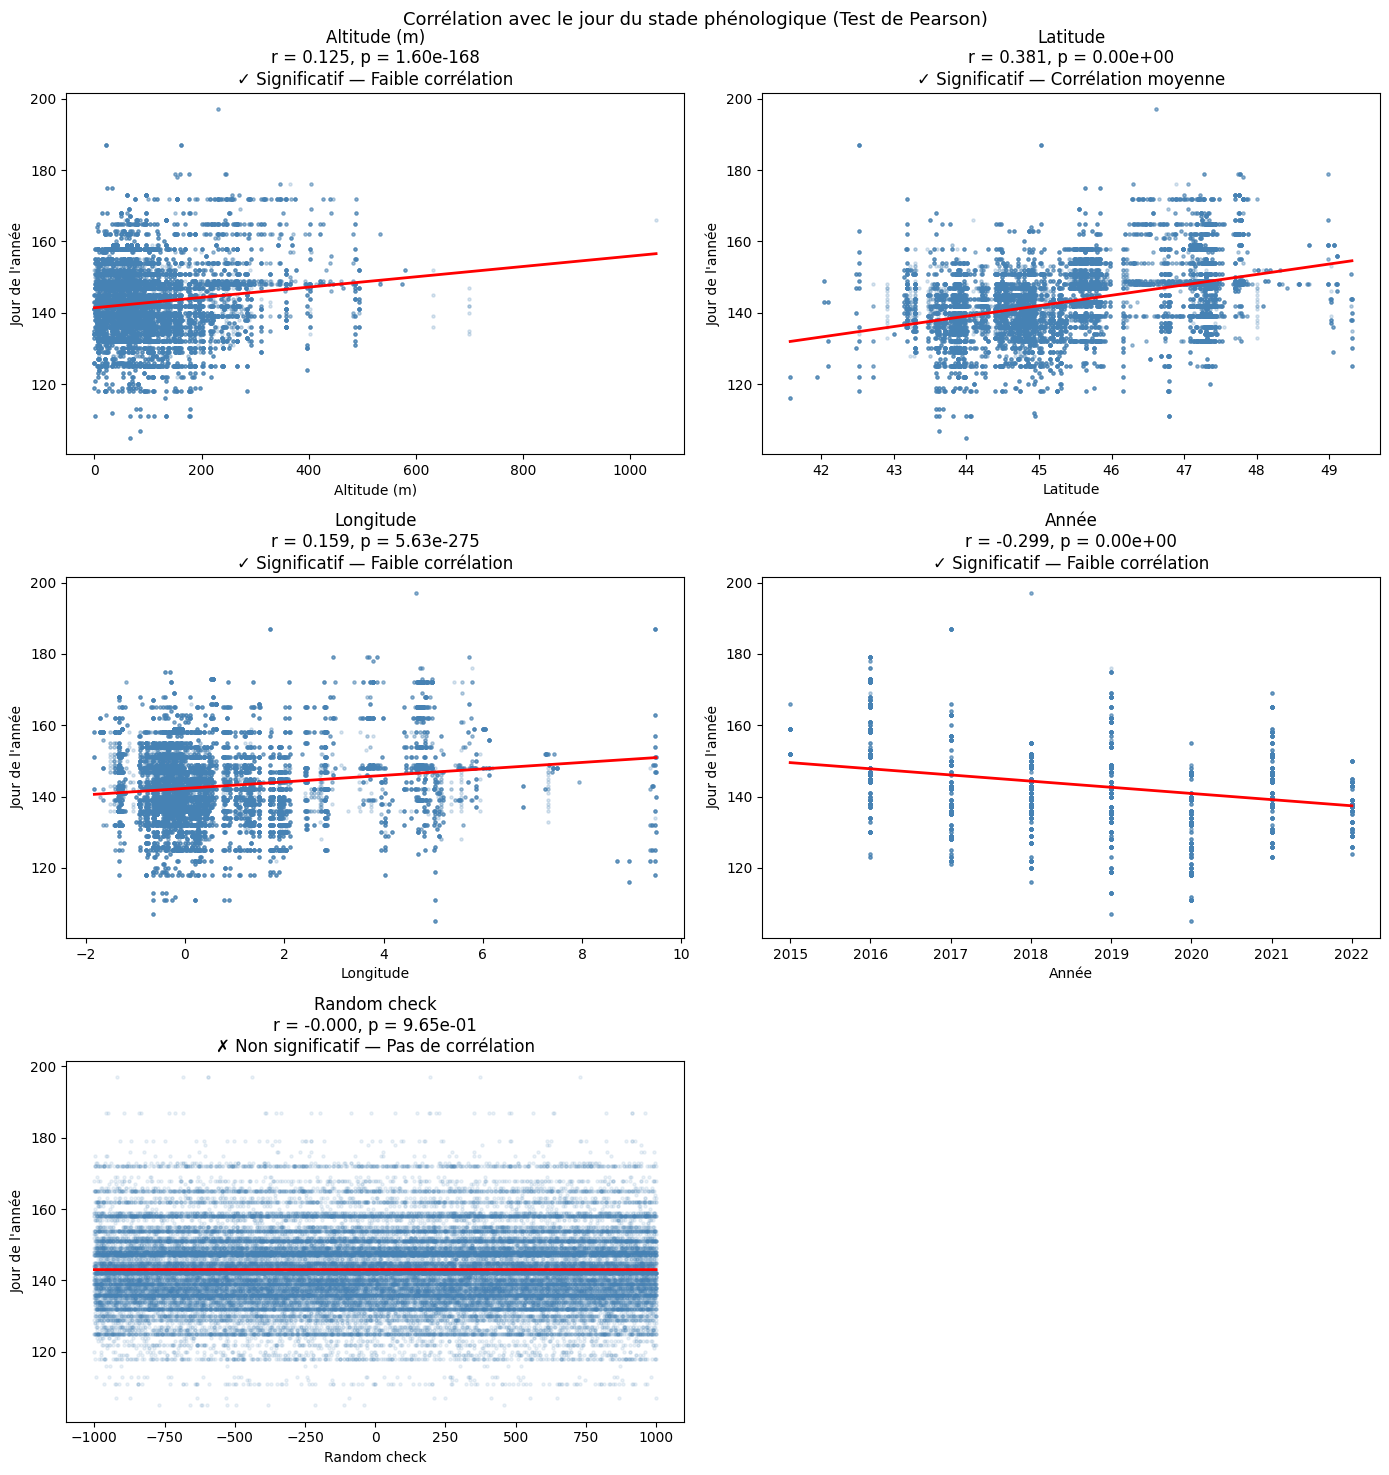

In [ ]:
#Test de corrélation

from scipy import stats

#variable avec lesquelles effectuer un test de corrélation
variables = {
    'altitude_du_site_ign': 'Altitude (m)',
    'latitude_du_site': 'Latitude',
    'longitude_du_site': 'Longitude',
    'annee': 'Année',
    'random_check' : 'Random check' #Pour vérification du bon fonctionnement - ne devrait montrer aucune corrélation ici
}

n_cols = 2
n_rows = -(-len(variables) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes_flat = axes.flatten()

for ax, (col, label) in zip(axes_flat, variables.items()):
    data = df_vigne[['jour_de_l_annee', col]].dropna()
    r, p_value = stats.pearsonr(data['jour_de_l_annee'], data[col])
    
    ax.scatter(data[col], data['jour_de_l_annee'], alpha=0.1, s=5, color='steelblue')
    
    slope, intercept, *_ = stats.linregress(data[col], data['jour_de_l_annee'])
    x_range = [data[col].min(), data[col].max()]
    ax.plot(x_range, [slope * x + intercept for x in x_range], color='red', linewidth=2)
    
    #Detérminatin du niveau de corrélation
    # Significativité statistique
    if p_value < 0.05:
        sig_marker = "✓ Significatif"
    else:
        sig_marker = "✗ Non significatif"

    # Force de la corrélation (basée sur |r|)
    #Niveaux de corrélation : https://numiqo.fr/tutorial/pearson-correlation
    abs_r = abs(r)
    if abs_r >= 0 and abs_r < 0.1:
        strength = "Pas de corrélation"
    elif abs_r >= 0.1 and abs_r < 0.3:
        strength = "Faible corrélation"
    elif abs_r >= 0.3 and abs_r < 0.5:
        strength = "Corrélation moyenne"
    elif abs_r >= 0.5 and abs_r < 0.8:
        strength = "Forte corrélation"
    else:
        strength = "Très forte corrélation"

    sig = f"{sig_marker} — {strength}"

    ax.set_title(f"{label}\nr = {r:.3f}, p = {p_value:.2e}\n{sig}")
    ax.set_xlabel(label)
    ax.set_ylabel("Jour de l'année")

# Masquer les subplots vides
for ax in axes_flat[len(variables):]:
    ax.set_visible(False)

plt.suptitle("Corrélation avec le jour du stade phénologique (Test de Pearson)", fontsize=13)
plt.tight_layout()
plt.show()

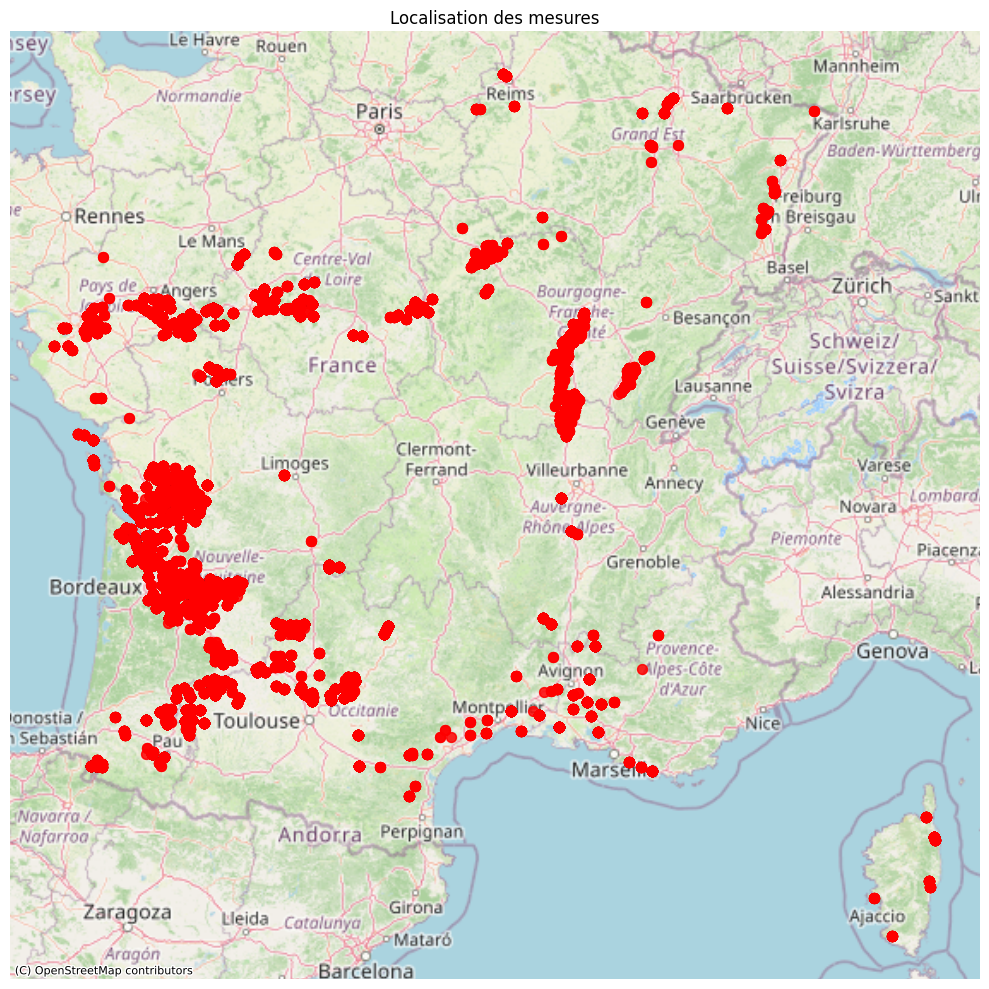

In [ ]:
#Représentation géographique

# Créer un GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_vigne,
    geometry=gpd.points_from_xy(df_vigne['longitude_du_site'], df_vigne['latitude_du_site']),
    crs='EPSG:4326'
)

gdf = gdf.to_crs(epsg=3857)

# Créer la carte
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(ax=ax, color='red', markersize=50, alpha=0.6)

# Ajouter le fond de carte
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

plt.title('Localisation des mesures')
plt.axis('off')
plt.tight_layout()
plt.show()

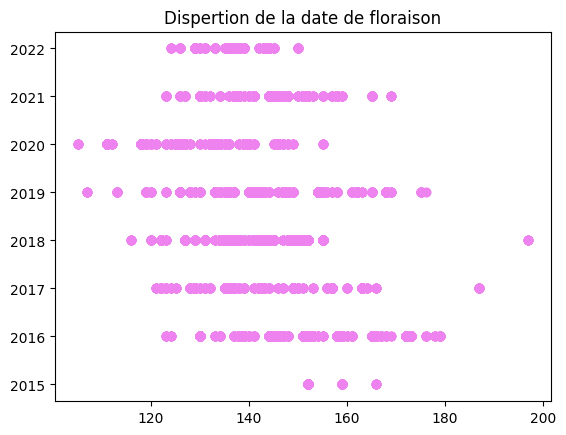

In [29]:
#Dispertion de la date de floraison
plt.scatter(df_vigne["jour_de_l_annee"], df_vigne["annee"], c='violet')
plt.title(f"Dispertion de la date de floraison")
plt.show()




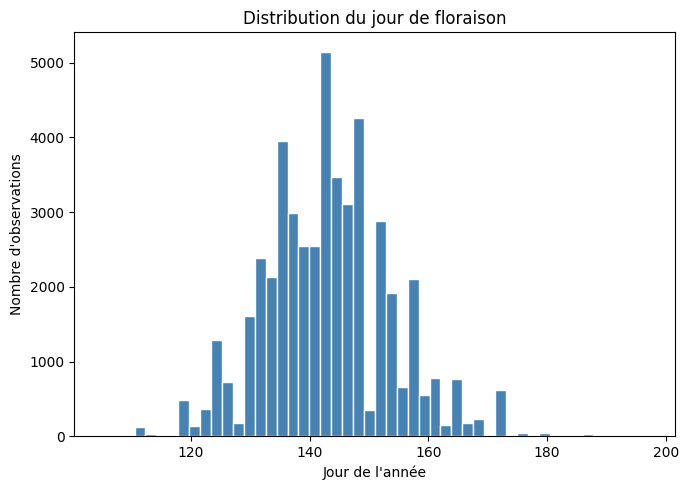

In [35]:
# Distribution du jour de floraison
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(df_vigne['jour_de_l_annee'], bins=50, color='steelblue', edgecolor='white')
ax.set_title("Distribution du jour de floraison")
ax.set_xlabel("Jour de l'année")
ax.set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

/tmp/ipykernel_629498/660720882.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_year, labels=annees, showfliers=False, patch_artist=True,


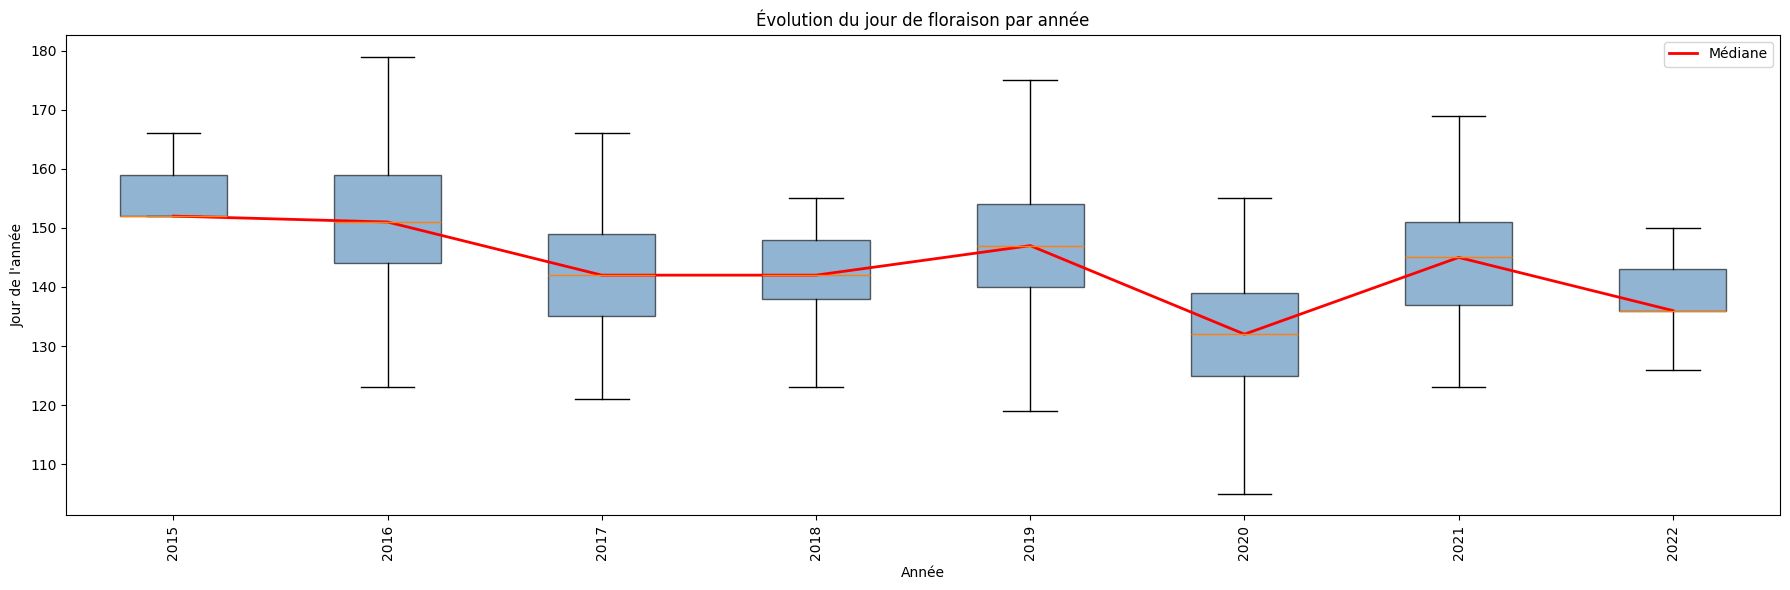

In [36]:
# Évolution temporelle : boxplot du jour de floraison par année
fig, ax = plt.subplots(figsize=(18, 6))

annees = sorted(df_vigne['annee'].unique())
data_by_year = [df_vigne[df_vigne['annee'] == a]['jour_de_l_annee'].values for a in annees]

ax.boxplot(data_by_year, labels=annees, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))

medians = [df_vigne[df_vigne['annee'] == a]['jour_de_l_annee'].median() for a in annees]
ax.plot(range(1, len(annees) + 1), medians, color='red', linewidth=2, label='Médiane')

ax.set_title("Évolution du jour de floraison par année")
ax.set_xlabel("Année")
ax.set_ylabel("Jour de l'année")
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

## Sauvegarde des données

In [37]:
df_vigne.to_csv(dstFolder+"phenologie.csv")